Mounted at /content/drive
Building flat features (this takes a few minutes on the full dataset)...
Train: (73818, 29), Val: (32350, 29)

Actual epochs run before stopping: 94


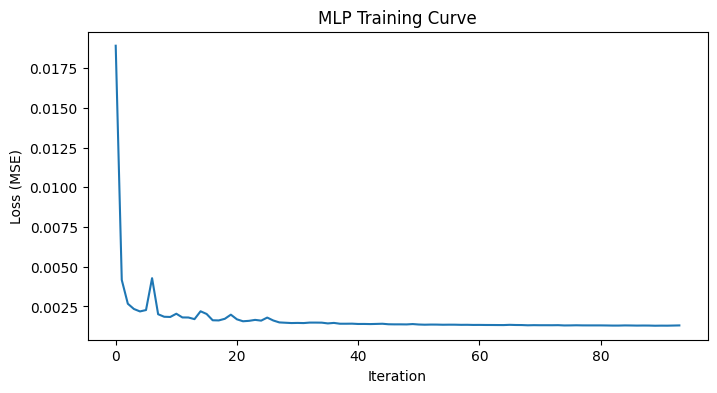


--- MLP — Validation ---
Overall MAE: 0.0467  RMSE: 0.0738  R2: 0.8746
  aggression_score — MAE: 0.0393  RMSE: 0.0641  R2: 0.8215
  line_shape_score — MAE: 0.0395  RMSE: 0.0616  R2: 0.9440
  oversteer_preference_score — MAE: 0.0613  RMSE: 0.0918  R2: 0.8583

--- MLP — Test (in-distribution) ---
Overall MAE: 0.0314  RMSE: 0.0516  R2: 0.9273
  aggression_score — MAE: 0.0384  RMSE: 0.0665  R2: 0.8255
  line_shape_score — MAE: 0.0153  RMSE: 0.0214  R2: 0.9945
  oversteer_preference_score — MAE: 0.0405  RMSE: 0.0559  R2: 0.9619

--- MLP — Test (zero-shot) ---
Overall MAE: 0.0368  RMSE: 0.0621  R2: 0.9454
  aggression_score — MAE: 0.0362  RMSE: 0.0656  R2: 0.9118
  line_shape_score — MAE: 0.0248  RMSE: 0.0375  R2: 0.9824
  oversteer_preference_score — MAE: 0.0494  RMSE: 0.0765  R2: 0.9420

Model saved.


In [1]:
# --- 05_model_mlp.ipynb ---
import pandas as pd
import numpy as np
import glob
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/f1-telemetry-ml'
labeled_path = f'{data_path}/labeled'
processed_path = f'{data_path}/processed'

target_cols = ['aggression_score', 'line_shape_score', 'oversteer_preference_score']

train_labels = pd.read_parquet(f'{labeled_path}/train_data.parquet')
val_labels = pd.read_parquet(f'{labeled_path}/val_data.parquet')
test_in_dist_labels = pd.read_parquet(f'{labeled_path}/test_in_dist_data.parquet')
test_zero_shot_labels = pd.read_parquet(f'{labeled_path}/test_zero_shot.parquet')

segmented_files = glob.glob(f'{processed_path}/corners_*.parquet')
segmented = pd.concat([pd.read_parquet(f) for f in segmented_files], ignore_index=True)

SAFE_COLUMNS = ['Throttle', 'Brake', 'Speed', 'nGear', 'RPM']
merge_keys = ['year', 'race', 'session_type', 'driver', 'lap_number', 'corner_number']

def build_flat_features(labels_df, segmented_df):
    merged = segmented_df.merge(labels_df[merge_keys + target_cols], on=merge_keys, how='inner')
    rows = []
    for keys, group in merged.groupby(merge_keys):
        row = dict(zip(merge_keys, keys))
        for col in SAFE_COLUMNS:
            row[f'{col}_mean'] = group[col].mean()
            row[f'{col}_std'] = group[col].std()
            row[f'{col}_min'] = group[col].min()
            row[f'{col}_max'] = group[col].max()
        for t in target_cols:
            row[t] = group[t].iloc[0]
        rows.append(row)
    return pd.DataFrame(rows)

print("Building flat features (this takes a few minutes on the full dataset)...")
train_df = build_flat_features(train_labels, segmented)
val_df = build_flat_features(val_labels, segmented)
test_in_dist_df = build_flat_features(test_in_dist_labels, segmented)
test_zero_shot_df = build_flat_features(test_zero_shot_labels, segmented)

feature_cols = [c for c in train_df.columns if c.endswith(('_mean', '_std', '_min', '_max'))]
print(f"Train: {train_df.shape}, Val: {val_df.shape}")

# --- Scale (MLP is sensitive to feature scale, unlike Random Forest) ---
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_in_dist_df[feature_cols] = scaler.transform(test_in_dist_df[feature_cols])
test_zero_shot_df[feature_cols] = scaler.transform(test_zero_shot_df[feature_cols])

# --- Train ---
# Hyperparameters, stated explicitly for the paper (Requirement 6):
# hidden layers (64, 32), ReLU activation, Adam solver, learning_rate_init=1e-3,
# max_iter=500 (max epochs, early stopping may cut this short), random_state=42
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=10
)
model.fit(train_df[feature_cols], train_df[target_cols])
print(f"\nActual epochs run before stopping: {model.n_iter_}")

# --- Training curve (Requirement 6) ---
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('MLP Training Curve')
plt.show()

# --- Evaluate on all three splits ---
def evaluate_split(df, split_name):
    preds = model.predict(df[feature_cols])
    mae = mean_absolute_error(df[target_cols], preds)
    rmse = mean_squared_error(df[target_cols], preds) ** 0.5
    r2 = r2_score(df[target_cols], preds)
    print(f"\n--- MLP — {split_name} ---")
    print(f"Overall MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}")
    for i, col in enumerate(target_cols):
        col_mae = mean_absolute_error(df[col], preds[:, i])
        col_rmse = mean_squared_error(df[col], preds[:, i]) ** 0.5
        col_r2 = r2_score(df[col], preds[:, i])
        print(f"  {col} — MAE: {col_mae:.4f}  RMSE: {col_rmse:.4f}  R2: {col_r2:.4f}")

evaluate_split(val_df, "Validation")
evaluate_split(test_in_dist_df, "Test (in-distribution)")
evaluate_split(test_zero_shot_df, "Test (zero-shot)")

# --- Save ---
os.makedirs(f'{data_path}/models', exist_ok=True)
joblib.dump(model, f'{data_path}/models/mlp_model.pkl')
joblib.dump(scaler, f'{data_path}/models/mlp_scaler.pkl')
print("\nModel saved.")